Task2 Machine Learning Model

In [1]:
import pandas as pd

In [8]:
df = pd.read_excel("Dataset.xlsx")

In [7]:
import os
os.chdir("E:\\Shraddha\\Project")

In [9]:
df.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [11]:
df = df[['experience_level', 'job_category', 'annual_salary_usd']]
df.head()

,experience_level,job_category,annual_salary_usd
0,Senior (6-9 yrs),AI Engineering,239000
1,Senior (6-9 yrs),AI Engineering,166000
2,Senior (6-9 yrs),AI Engineering,360000
3,Senior (6-9 yrs),Data Engineering,161000
4,Lead (10+ yrs),Product,283000


In [13]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,annual_salary_usd,experience_level_Lead (10+ yrs),experience_level_Mid (3-5 yrs),experience_level_Senior (6-9 yrs),job_category_Architecture,job_category_Business,job_category_Data Engineering,job_category_Data Science,job_category_Governance,job_category_Infrastructure,job_category_ML Operations,job_category_Product,job_category_Research,job_category_Robotics,job_category_Security
0,239000,False,False,True,False,False,False,False,False,False,False,False,False,False,False
1,166000,False,False,True,False,False,False,False,False,False,False,False,False,False,False
2,360000,False,False,True,False,False,False,False,False,False,False,False,False,False,False
3,161000,False,False,True,False,False,True,False,False,False,False,False,False,False,False
4,283000,True,False,False,False,False,False,False,False,False,False,True,False,False,False


In [31]:
x = df.drop('annual_salary_usd', axis=1)
y = df['annual_salary_usd']

In [32]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10)

In [33]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
y_pred = model.predict(x_test)

In [36]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print(score)

0.3195566131030503


In [37]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor()
dt_model.fit(x_train, y_train)

dt_pred = dt_model.predict(x_test)

from sklearn.metrics import r2_score
print("Decision Tree Score:", r2_score(y_test, dt_pred))

Decision Tree Score: 0.3028562884813346


In [38]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()
rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)

print("Random Forest Score:", r2_score(y_test, rf_pred))

Random Forest Score: 0.30110163252173294


In [39]:
print("Linear Regression:", r2_score(y_test, y_pred))
print("Decision Tree:", r2_score(y_test, dt_pred))
print("Random Forest:", r2_score(y_test, rf_pred))

Linear Regression: 0.3195566131030503
Decision Tree: 0.3028562884813346
Random Forest: 0.30110163252173294


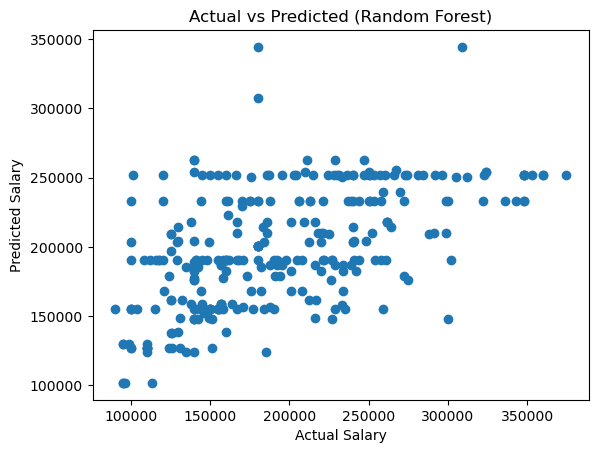

In [40]:
import matplotlib.pyplot as plt

plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

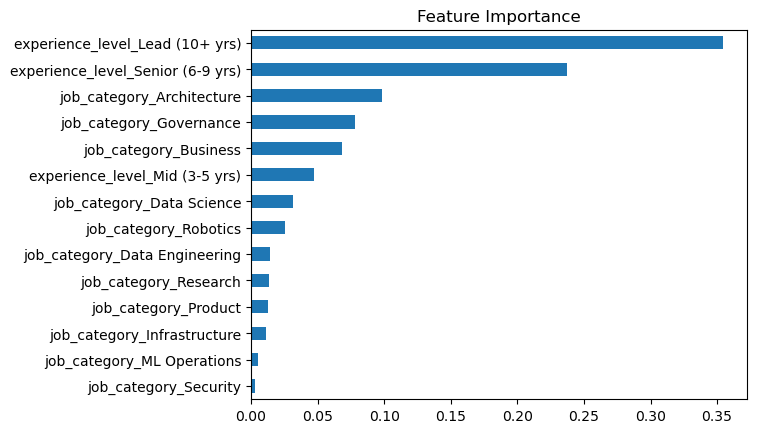

In [41]:
import pandas as pd

importance = rf_model.feature_importances_
features = x.columns

feat_imp = pd.Series(importance, index=features)
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()